# Assignment: Data Wrangling

### Reading material: `tidy_data.pdf`

**Q1.** This question provides some practice cleaning variables which have common problems.
1. For `./data/airbnb_hw.csv`, clean the `Price` variable as well as you can, and explain the choices you make. How many missing values do you end up with? (Hint: What happens to the formatting when a price goes over 999 dollars, say from 675 to 1,112?)
2. For the Minnesota police use of for data, `./data/mn_police_use_of_force.csv`, clean the `subject_injury` variable, handling the NA's; this gives a value `Yes` when a person was injured by police, and `No` when no injury occurred. What proportion of the values are missing? Is this a concern? Cross-tabulate your cleaned `subject_injury` variable with the `force_type` variable. Are there any patterns regarding when the data are missing? 

**Q2.** Go to https://sharkattackfile.net/ and download their dataset on shark attacks (Hint: `GSAF5.xls`).

1. Open the shark attack file using Pandas. It is probably not a csv file, so `read_csv` won't work.
2. Drop any columns that do not contain data.
3. Clean the year variable. Describe the range of values you see. Filter the rows to focus on attacks since 1940. Are attacks increasing, decreasing, or remaining constant over time?
4. Clean the Age variable and make a histogram of the ages of the victims.
5. What proportion of victims are male?
6. Clean the `Type` variable so it only takes three values: Provoked and Unprovoked and Unknown. What proportion of attacks are unprovoked?

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** Yifan Qiao

**Date:** 09/05/26

Q1.1

In [16]:
import pandas as pd
df = pd.read_csv("./data/airbnb_hw.csv")
df.head()
df["Price"].value_counts(dropna=False)
price_numeric = pd.to_numeric(df["Price"], errors="coerce")
problem_rows = df[price_numeric.isna() & df["Price"].notna()]
display(problem_rows.head(20))
df["Price"] = (
    df["Price"]
    .astype("string")
    .str.replace(",", "", regex=False)
)
df["Price"] = pd.to_numeric(df["Price"], errors="coerce")
display(df["Price"].head(20))
missing_price = df["Price"].isna().sum()
print(missing_price)

,Host Id,Host Since,Name,Neighbourhood,Property Type,Review Scores Rating (bin),Room Type,Zipcode,Beds,Number of Records,Number Of Reviews,Price,Review Scores Rating
101,8730,2/27/2009,Comfort & Convenience,Manhattan,Condominium,100.0,Entire home/apt,10003.0,6.0,1,4,"1,990",100.0
263,34915,8/30/2009,Luxurious 2-Floor Manhattan Mansion,Manhattan,Apartment,NaN,Entire home/apt,10075.0,2.0,1,0,"1,000",NaN
764,112879,4/23/2010,Modern Luxury Meets Old Money Charm,Brooklyn,Apartment,NaN,Entire home/apt,11206.0,5.0,1,0,"1,200",NaN
1272,214148,8/26/2010,"LARGE, COMFY 1BDR W/CHARACTER!!!",Brooklyn,Apartment,90.0,Entire home/apt,11216.0,1.0,1,30,"1,000",92.0
1275,213266,8/26/2010,Beautiful 1 Bedroom in Nolita/Soho,Manhattan,Apartment,75.0,Entire home/apt,10012.0,2.0,1,2,"5,000",76.0
1476,256239,10/8/2010,Beautiful 3 bedroom in Manhattan,Manhattan,Apartment,NaN,Private room,10025.0,NaN,1,0,"3,000",NaN
1846,319077,12/14/2010,HUGE loft for film & photoshoots,Brooklyn,Loft,95.0,Entire home/apt,11238.0,4.0,1,6,"1,500",97.0
1973,351384,1/17/2011,"For Walter, King Size Bed",Brooklyn,Other,NaN,Entire home/apt,11211.0,1.0,1,0,"1,200",NaN
1977,351938,1/18/2011,All Star/Fashion weekend/VDAY Pad,Brooklyn,Loft,NaN,Entire home/apt,11231.0,1.0,1,0,"1,800",NaN
2095,391612,2/14/2011,"Victorian House, Express + More!",Brooklyn,House,95.0,Entire home/apt,11226.0,8.0,1,6,"1,300",97.0


0     145
1      37
2      28
3     199
4     549
5     149
6     250
7      90
8     270
9     290
10    170
11     59
12     49
13     68
14    285
15     75
16    145
17    100
18    150
19    700
Name: Price, dtype: Int64

0


The Price variable contained inconsistent formatting. I removed the commas from the Price strings and then converted the column to a numeric data type using pd.to_numeric(). After cleaning, I checked the data type and counted the remaining missing values to verify the result. There were 0 missing values in the Price variable.

Q1.2

In [17]:
import pandas as pd
police = pd.read_csv("./data/mn_police_use_of_force.csv")
missing_prop = police["subject_injury"].isna().mean()
print(missing_prop)
injury_clean = police["subject_injury"].fillna("Missing")
pd.crosstab(
    police["force_type"],
    injury_clean
)

0.7619342359767892


subject_injury,Missing,No,Yes
force_type,,,
Baton,2,0,2
Bodily Force,7051,1093,1286
Chemical Irritant,1421,131,41
Firearm,0,2,0
Gun Point Display,27,33,44
Improvised Weapon,74,34,40
Less Lethal,87,0,0
Less Lethal Projectile,0,1,2
Maximal Restraint Technique,170,0,0


Yes, this is a concern because about 76.19% of the observations are missing. With such a large amount of missing data, the available injury information may not be representative of all police use-of-force incidents. Chemical Irritant has the most missing values.

Q2

Minimum year: 1940.0
Maximum year: 2026.0
80.1461289869327 %
Percentage: 73.94969790642124 %


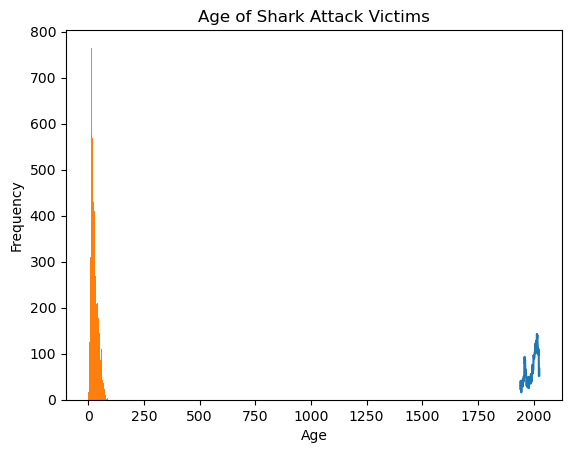

In [46]:
import pandas as pd
shark = pd.read_excel("./data/GSAF5.xls")
shark.head()
shark = shark.dropna(axis=1, how="all")
shark.head()

shark["Year"] = pd.to_numeric(shark["Year"], errors="coerce")
shark_1940 = shark[shark["Year"] >= 1940]
print("Minimum year:", shark_1940["Year"].min())
print("Maximum year:", shark_1940["Year"].max())
attacks_per_year = shark_1940["Year"].value_counts().sort_index()
attacks_per_year.plot(
    kind="line",
    xlabel="Year",
    ylabel="Number of Attacks",
    title="Shark Attacks Since 1940"
)

shark["Age"] = pd.to_numeric(shark["Age"], errors="coerce")
shark["Age"].dropna().plot(
    kind="hist",
    bins=20,
    xlabel="Age",
    title="Age of Shark Attack Victims"
)

shark["Sex"].value_counts(dropna=False)
male_prop = (shark["Sex"] == "M").mean()
print(male_prop * 100, "%")

shark["Type"].value_counts(dropna=False)
shark["Type"] = shark["Type"].str.strip().str.lower()
shark["Type"] = shark["Type"].replace({
    "provoked": "Provoked",
    "unprovoked": "Unprovoked"
})

shark.loc[~shark["Type"].isin(["Provoked", "Unprovoked"]), "Type"] = "Unknown"
shark["Type"].value_counts()
unprovoked_prop = (shark["Type"] == "Unprovoked").mean()
print("Percentage:", unprovoked_prop * 100, "%")

The years ranged from 1940 to 2026. The number of recorded shark attacks generally increased over time. The proportion of males are 80.1%. The proportion of attacks that are unprovoked 73.9%.

## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** [To be provided]
- **AI tool and model used:** [To be provided]

### *Prompts used

1. [Paste prompt]
2. [Paste follow-up prompt]

### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]

1. ...
2. ...

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept / modify / reject | ... |
| 2 | Accept / modify / reject | ... |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

In [ ]:
# Your Phase 2 solution to the problem goes here.


### *Reflection on AI assistance
In your own words without generative AI.

[In 150–300 words, describe the main improvements, AI mistakes or limitations, how the final solution was verified, and any remaining concerns.]